# MuSiQue exploratory data analysis

## 1. Dataset contract and integrity audit

This section establishes what data was actually loaded before any substantive EDA or model runs. It checks the top-level schema, split sizes, identifier structure, nested paragraph and decomposition records, and the references connecting decomposition steps to supporting paragraphs.

The audit is intentionally limited to the MuSiQue data itself. It does not use the outdated project proposal in the repository. Its output is a descriptive validation report, not a modification of the source data.

In [5]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path) -> Path:
    """Find the repository root from either the repo or notebook directory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "Code" / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data" / "MuSiQue" / "clean"
FIG_DIR = REPO_ROOT / "Code" / "notebooks" / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILES = {
    "train": DATA_DIR / "train.json",
    "validation": DATA_DIR / "validation.json",
}
EXPECTED_COLUMNS = (
    "id",
    "paragraphs",
    "question",
    "question_decomposition",
    "answer",
    "answer_aliases",
    "answerable",
)

### Data source and loading behavior

The notebook reuses the paths produced by `Code/scripts/get_MuSiQue_dataset.py`. That script loads `dgslibisey/MuSiQue` and writes newline-delimited JSON to `data/MuSiQue/clean/train.json` and `validation.json`. Despite the `.json` suffix, each file contains one JSON record per line, so `pandas.read_json(..., lines=True)` is required.

If the files are missing, run the download script from the repository root before continuing. The explicit missing-file error below prevents the notebook from silently analyzing partial or unintended data.

In [6]:
missing_files = [path for path in DATA_FILES.values() if not path.exists()]
if missing_files:
    missing_display = "\n".join(f"- {path}" for path in missing_files)
    raise FileNotFoundError(
        "Required MuSiQue files are missing:\n"
        f"{missing_display}\n"
        "Run: python Code/scripts/get_MuSiQue_dataset.py"
    )

splits = {
    split_name: pd.read_json(path, lines=True)
    for split_name, path in DATA_FILES.items()
}

dataset_inventory = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": len(frame),
            "columns": len(frame.columns),
            "unique_ids": frame["id"].nunique(dropna=False),
            "answerable_true": int(frame["answerable"].eq(True).sum()),
            "rows_with_20_paragraphs": int(
                frame["paragraphs"].map(lambda value: isinstance(value, list) and len(value) == 20).sum()
            ),
        }
        for split_name, frame in splits.items()
    ]
).set_index("split")

display(dataset_inventory)
display(pd.DataFrame({name: frame.dtypes.astype(str) for name, frame in splits.items()}))

,rows,columns,unique_ids,answerable_true,rows_with_20_paragraphs
split,,,,,
train,19938,7,19938,19938,19917
validation,2417,7,2417,2417,2401


,train,validation
id,str,str
paragraphs,object,object
question,str,str
question_decomposition,object,object
answer,str,str
answer_aliases,object,object
answerable,bool,bool


### Integrity rules

The audit checks the following contracts for every split:

1. The seven expected top-level columns are present, with no unexpected columns or missing values.
2. IDs are unique and follow MuSiQue's encoded hop/graph pattern, such as `2hop__...`, `3hop1__...`, or `4hop3__...`.
3. `paragraphs` and `question_decomposition` are lists of records with the required nested keys.
4. The encoded hop count equals the number of decomposition steps, and component IDs in the composite ID match the ordered decomposition IDs.
5. Every `paragraph_support_idx` is in range, points to the paragraph with that same index, and points to a paragraph marked as supporting. The complete set of referenced paragraphs must equal the marked support set.
6. The final answer equals the last decomposition answer after whitespace and case normalization.
7. All records are answerable, which confirms that the current source is MuSiQue-Ans rather than MuSiQue-Full.

Duplicate normalized question text and records containing other than 20 paragraphs are warnings rather than failures. They deserve inspection, but do not necessarily indicate broken records. All structural and referential violations are failures.

In [7]:
ID_PATTERN = re.compile(
    r"^(?P<hops>[2-4])hop(?P<shape>[1-3]?)__(?P<components>\d+(?:_\d+)*)$"
)
PARAGRAPH_KEYS = {"idx", "title", "paragraph_text", "is_supporting"}
DECOMPOSITION_KEYS = {"id", "question", "answer", "paragraph_support_idx"}


def normalize_text(value: object) -> str:
    return str(value).strip().casefold()


def audit_split(frame: pd.DataFrame) -> dict[str, int]:
    missing_columns = set(EXPECTED_COLUMNS) - set(frame.columns)
    unexpected_columns = set(frame.columns) - set(EXPECTED_COLUMNS)
    counts = {
        "schema_column_violations": len(missing_columns) + len(unexpected_columns),
        "missing_top_level_values": int(frame.isna().sum().sum()),
        "duplicate_ids": 0,
        "duplicate_normalized_questions": 0,
        "malformed_ids": 0,
        "invalid_paragraph_records": 0,
        "paragraph_index_violations": 0,
        "invalid_decomposition_records": 0,
        "hop_decomposition_mismatches": 0,
        "component_id_mismatches": 0,
        "support_reference_violations": 0,
        "support_set_mismatches": 0,
        "final_answer_mismatches": 0,
        "non_answerable_rows": 0,
        "non_20_paragraph_rows": 0,
    }
    if missing_columns:
        return counts

    counts["duplicate_ids"] = int(frame["id"].duplicated().sum())
    counts["duplicate_normalized_questions"] = int(
        frame["question"].map(normalize_text).duplicated().sum()
    )
    counts["non_answerable_rows"] = int(frame["answerable"].ne(True).sum())

    for row in frame.itertuples(index=False):
        identifier_match = ID_PATTERN.fullmatch(str(row.id))
        if identifier_match is None:
            counts["malformed_ids"] += 1

        paragraphs = row.paragraphs
        decomposition = row.question_decomposition

        paragraphs_valid = isinstance(paragraphs, list) and all(
            isinstance(paragraph, dict) and PARAGRAPH_KEYS.issubset(paragraph)
            for paragraph in paragraphs
        )
        if not paragraphs_valid:
            counts["invalid_paragraph_records"] += 1
            continue

        if [paragraph["idx"] for paragraph in paragraphs] != list(range(len(paragraphs))):
            counts["paragraph_index_violations"] += 1

        decomposition_valid = isinstance(decomposition, list) and all(
            isinstance(step, dict) and DECOMPOSITION_KEYS.issubset(step)
            for step in decomposition
        )
        if not decomposition_valid:
            counts["invalid_decomposition_records"] += 1
            continue

        if identifier_match is not None:
            encoded_hops = int(identifier_match.group("hops"))
            encoded_components = identifier_match.group("components").split("_")
            observed_components = [str(step["id"]) for step in decomposition]
            if encoded_hops != len(decomposition):
                counts["hop_decomposition_mismatches"] += 1
            if encoded_components != observed_components:
                counts["component_id_mismatches"] += 1

        referenced_support = []
        support_reference_is_invalid = False
        for step in decomposition:
            support_idx = step["paragraph_support_idx"]
            reference_is_valid = (
                isinstance(support_idx, int)
                and 0 <= support_idx < len(paragraphs)
                and paragraphs[support_idx]["idx"] == support_idx
            )
            if not reference_is_valid:
                support_reference_is_invalid = True
                continue
            referenced_support.append(support_idx)
            if paragraphs[support_idx]["is_supporting"] is not True:
                support_reference_is_invalid = True

        if support_reference_is_invalid:
            counts["support_reference_violations"] += 1

        marked_support = {
            paragraph["idx"]
            for paragraph in paragraphs
            if paragraph["is_supporting"] is True
        }
        if set(referenced_support) != marked_support:
            counts["support_set_mismatches"] += 1

        if decomposition and normalize_text(row.answer) != normalize_text(decomposition[-1]["answer"]):
            counts["final_answer_mismatches"] += 1

        if len(paragraphs) != 20:
            counts["non_20_paragraph_rows"] += 1

    return counts


audit_counts = {split_name: audit_split(frame) for split_name, frame in splits.items()}

CHECK_LABELS = {
    "schema_column_violations": "Missing or unexpected columns",
    "missing_top_level_values": "Missing top-level values",
    "duplicate_ids": "Duplicate IDs",
    "duplicate_normalized_questions": "Duplicate normalized questions",
    "malformed_ids": "Malformed composite IDs",
    "invalid_paragraph_records": "Invalid paragraph records",
    "paragraph_index_violations": "Non-sequential paragraph indexes",
    "invalid_decomposition_records": "Invalid decomposition records",
    "hop_decomposition_mismatches": "Hop/decomposition mismatches",
    "component_id_mismatches": "Composite/decomposition ID mismatches",
    "support_reference_violations": "Invalid or unmarked support references",
    "support_set_mismatches": "Referenced/marked support-set mismatches",
    "final_answer_mismatches": "Final/decomposition answer mismatches",
    "non_answerable_rows": "Non-answerable rows",
    "non_20_paragraph_rows": "Rows without 20 paragraphs",
}
WARNING_CHECKS = {"duplicate_normalized_questions", "non_20_paragraph_rows"}

audit_table = pd.DataFrame(
    {
        "check": [CHECK_LABELS[key] for key in CHECK_LABELS],
        **{
            split_name: [counts[key] for key in CHECK_LABELS]
            for split_name, counts in audit_counts.items()
        },
    },
    index=list(CHECK_LABELS),
)

def check_status(check_name: str) -> str:
    has_findings = any(audit_counts[split_name][check_name] > 0 for split_name in splits)
    if not has_findings:
        return "PASS"
    return "WARN" if check_name in WARNING_CHECKS else "FAIL"


audit_table["status"] = [check_status(check_name) for check_name in audit_table.index]
audit_table = audit_table.reset_index(drop=True)
display(audit_table)

,check,train,validation,status
0,Missing or unexpected columns,0,0,PASS
1,Missing top-level values,0,0,PASS
2,Duplicate IDs,0,0,PASS
3,Duplicate normalized questions,42,6,WARN
4,Malformed composite IDs,0,0,PASS
5,Invalid paragraph records,0,0,PASS
6,Non-sequential paragraph indexes,0,0,PASS
7,Invalid decomposition records,0,0,PASS
8,Hop/decomposition mismatches,0,0,PASS
9,Composite/decomposition ID mismatches,0,0,PASS


### Saved audit artifact

The next cell turns the inventory and validation results into a compact report table. Following the project artifact convention, the same descriptive stem is exported twice to `Code/notebooks/figs`: once as PDF and once as SVG. Both files are derived from the same Matplotlib figure, so their content remains synchronized.

Status meanings:

- **PASS:** no instances violated the rule.
- **WARN:** non-blocking cases were found and should be characterized later.
- **FAIL:** a structural or referential contract was violated and should be resolved before downstream EDA.

,saved_artifact
0,Code/notebooks/figs/dataset_schema_and_integri...
1,Code/notebooks/figs/dataset_schema_and_integri...


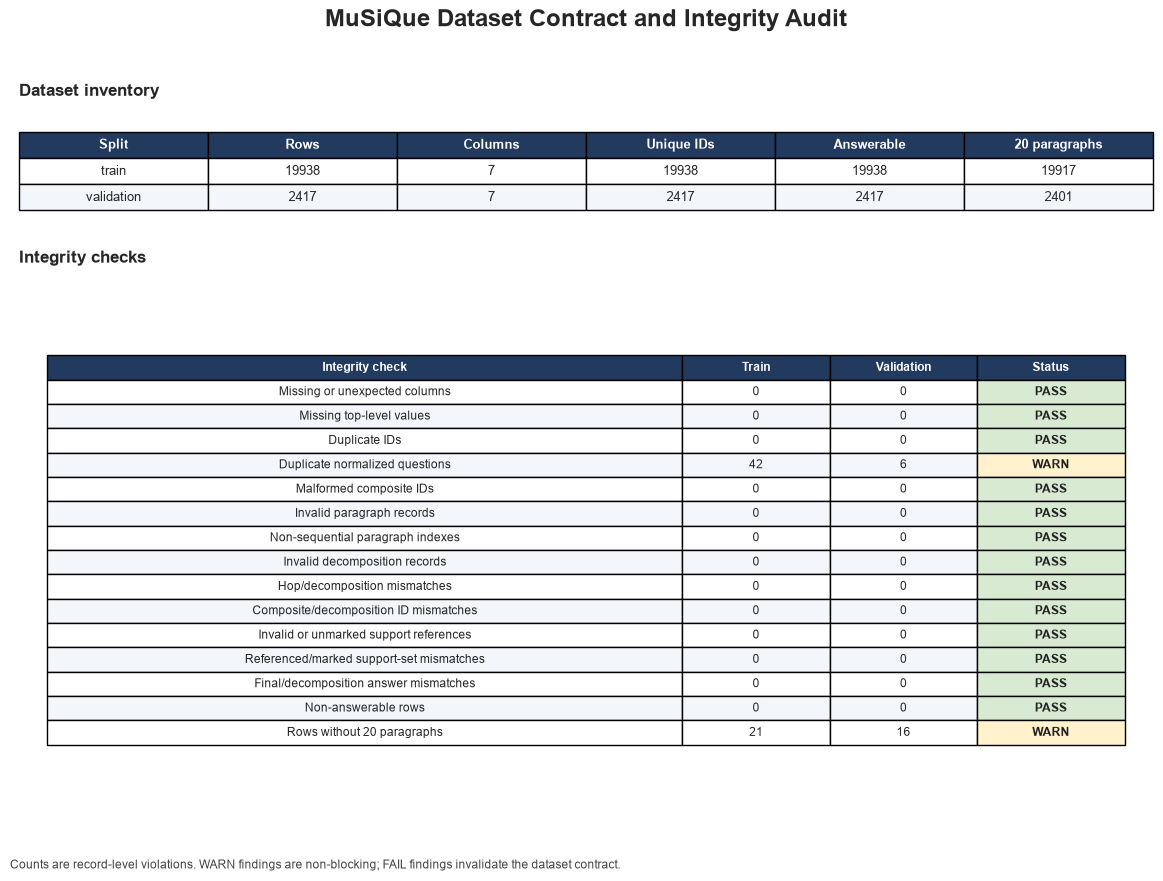

In [8]:
inventory_for_figure = dataset_inventory.reset_index().copy()
inventory_for_figure.columns = [
    "Split",
    "Rows",
    "Columns",
    "Unique IDs",
    "Answerable",
    "20 paragraphs",
]
audit_for_figure = audit_table.rename(
    columns={"check": "Integrity check", "train": "Train", "validation": "Validation", "status": "Status"}
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    gridspec_kw={"height_ratios": [1.0, 4.3]},
)
fig.patch.set_facecolor("white")
fig.suptitle("MuSiQue Dataset Contract and Integrity Audit", fontsize=17, fontweight="bold", y=0.98)

for axis in axes:
    axis.axis("off")

axes[0].set_title("Dataset inventory", loc="left", fontsize=12, fontweight="bold", pad=8)
inventory_artist = axes[0].table(
    cellText=inventory_for_figure.values,
    colLabels=inventory_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)
inventory_artist.auto_set_font_size(False)
inventory_artist.set_fontsize(9)
inventory_artist.scale(1, 1.45)

axes[1].set_title("Integrity checks", loc="left", fontsize=12, fontweight="bold", pad=8)
audit_artist = axes[1].table(
    cellText=audit_for_figure.values,
    colLabels=audit_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.56, 0.13, 0.13, 0.13],
    loc="center",
)
audit_artist.auto_set_font_size(False)
audit_artist.set_fontsize(8.5)
audit_artist.scale(1, 1.35)

for table_artist in (inventory_artist, audit_artist):
    for (row_index, _), cell in table_artist.get_celld().items():
        if row_index == 0:
            cell.set_facecolor("#223A5E")
            cell.set_text_props(color="white", fontweight="bold")
        elif row_index % 2 == 0:
            cell.set_facecolor("#F3F6FA")

status_colors = {"PASS": "#D9EAD3", "WARN": "#FFF2CC", "FAIL": "#F4CCCC"}
status_column = list(audit_for_figure.columns).index("Status")
for row_index, status in enumerate(audit_for_figure["Status"], start=1):
    status_cell = audit_artist[(row_index, status_column)]
    status_cell.set_facecolor(status_colors[status])
    status_cell.set_text_props(fontweight="bold", color="#222222")

fig.text(
    0.02,
    0.025,
    "Counts are record-level violations. WARN findings are non-blocking; FAIL findings invalidate the dataset contract.",
    fontsize=8.5,
    color="#444444",
)
fig.tight_layout(rect=[0.015, 0.055, 0.985, 0.955])

artifact_stem = "dataset_schema_and_integrity_audit"
artifact_paths = []
for file_format in ("pdf", "svg"):
    artifact_path = FIG_DIR / f"{artifact_stem}.{file_format}"
    fig.savefig(artifact_path, format=file_format, bbox_inches="tight")
    artifact_paths.append(artifact_path)

display(pd.DataFrame({"saved_artifact": [str(path.relative_to(REPO_ROOT)) for path in artifact_paths]}))
plt.show()

### Interpretation

Structural failures should stop downstream work because they can corrupt hop labels, support annotations, or final-answer labels. Warnings are retained as explicit counts so later EDA can investigate whether repeated question wording or variable paragraph counts create experimental confounds.

Once this contract passes, the next EDA section can characterize hop-count and reasoning-graph coverage without repeatedly revalidating the nested data model.

## 2. Experimental coverage

This section measures how MuSiQue's reasoning structures are represented in each split. The purpose is to identify imbalances before selecting questions for expensive solver, critic, activation-caching, SAE, and causal-intervention runs. A random subset that mirrors the full dataset may contain very few examples from the rare graph shapes, which would make comparisons across reasoning structures unreliable.

The analysis reuses the validated `splits`, `ID_PATTERN`, `normalize_text`, and `FIG_DIR` objects created in section 1. It does not reload or modify the source records.

### Coverage and reuse definitions

MuSiQue encodes its reasoning structure at the start of each composite ID. `2hop` is the single two-hop graph shape; `3hop1`, `3hop2`, `4hop1`, `4hop2`, and `4hop3` distinguish the five three-hop and four-hop shapes. Counts and percentages are calculated within each split so train and validation remain directly comparable despite their different sizes.

The reuse profile measures final-answer text, supporting-paragraph titles, and component-question IDs. For each feature, the repeated-occurrence rate is `(total occurrences - unique values) / total occurrences`. This is not treated as duplication or leakage: MuSiQue deliberately composes multihop questions from reusable single-hop material. Instead, the metric shows why later experimental sampling and model evaluation may need grouping or stratification. Cross-split overlap is intentionally deferred to the dedicated leakage audit.

In [9]:
GRAPH_ORDER = ("2hop", "3hop1", "3hop2", "4hop1", "4hop2", "4hop3")
GRAPH_LABELS = {
    "2hop": "2-hop",
    "3hop1": "3-hop shape 1",
    "3hop2": "3-hop shape 2",
    "4hop1": "4-hop shape 1",
    "4hop2": "4-hop shape 2",
    "4hop3": "4-hop shape 3",
}
HOP_ORDER = (2, 3, 4)

coverage_records = []
for split_name, frame in splits.items():
    graph_codes = frame["id"].str.extract(r"^([2-4]hop[1-3]?)__", expand=False)
    graph_counts = graph_codes.value_counts().reindex(GRAPH_ORDER, fill_value=0)
    for graph_code, count in graph_counts.items():
        coverage_records.append(
            {
                "split": split_name,
                "graph_code": graph_code,
                "graph_shape": GRAPH_LABELS[graph_code],
                "hop_count": int(graph_code[0]),
                "count": int(count),
                "split_share_pct": 100 * int(count) / len(frame),
            }
        )

graph_coverage = pd.DataFrame(coverage_records)
hop_coverage = (
    graph_coverage.groupby(["split", "hop_count"], as_index=False)["count"]
    .sum()
    .assign(
        split_share_pct=lambda table: table["count"]
        / table.groupby("split")["count"].transform("sum")
        * 100
    )
)


def summarize_reuse(values: list[str]) -> dict[str, float | int]:
    value_counts = pd.Series(values, dtype="string").value_counts()
    total_occurrences = int(value_counts.sum())
    unique_values = int(len(value_counts))
    return {
        "total_occurrences": total_occurrences,
        "unique_values": unique_values,
        "values_used_more_than_once": int(value_counts.gt(1).sum()),
        "repeated_occurrences": total_occurrences - unique_values,
        "repeated_occurrence_pct": 100 * (total_occurrences - unique_values) / total_occurrences,
        "maximum_occurrences_for_one_value": int(value_counts.max()),
    }


reuse_records = []
for split_name, frame in splits.items():
    feature_values = {
        "Final answers": [normalize_text(answer) for answer in frame["answer"]],
        "Supporting titles": [
            normalize_text(paragraph["title"])
            for paragraphs in frame["paragraphs"]
            for paragraph in paragraphs
            if paragraph["is_supporting"] is True
        ],
        "Component question IDs": [
            str(step["id"])
            for decomposition in frame["question_decomposition"]
            for step in decomposition
        ],
    }
    for feature_name, values in feature_values.items():
        reuse_records.append(
            {"split": split_name, "feature": feature_name, **summarize_reuse(values)}
        )

reuse_profile = pd.DataFrame(reuse_records)

rarest_strata = (
    graph_coverage.sort_values(["split", "count"])
    .groupby("split", as_index=False)
    .first()[["split", "graph_shape", "count", "split_share_pct"]]
)

display(
    graph_coverage[["split", "graph_shape", "count", "split_share_pct"]]
    .assign(split_share_pct=lambda table: table["split_share_pct"].round(2))
    .rename(columns={"split_share_pct": "split_share_pct (%)"})
)
display(
    reuse_profile.assign(
        repeated_occurrence_pct=lambda table: table["repeated_occurrence_pct"].round(1)
    )
)
display(
    rarest_strata.assign(split_share_pct=lambda table: table["split_share_pct"].round(2))
    .rename(columns={"split_share_pct": "split_share_pct (%)"})
)

,split,graph_shape,count,split_share_pct (%)
0,train,2-hop,14376,72.10
1,train,3-hop shape 1,3737,18.74
2,train,3-hop shape 2,650,3.26
3,train,4-hop shape 1,648,3.25
4,train,4-hop shape 2,127,0.64
5,train,4-hop shape 3,400,2.01
6,validation,2-hop,1252,51.80
7,validation,3-hop shape 1,568,23.50
8,validation,3-hop shape 2,192,7.94
9,validation,4-hop shape 1,246,10.18


,split,feature,total_occurrences,unique_values,values_used_more_than_once,repeated_occurrences,repeated_occurrence_pct,maximum_occurrences_for_one_value
0,train,Final answers,19938,2057,1674,17881,89.7,113
1,train,Supporting titles,46613,12304,5233,34309,73.6,249
2,train,Component question IDs,46613,14589,6043,32024,68.7,50
3,validation,Final answers,2417,738,383,1679,69.5,34
4,validation,Supporting titles,6404,2328,880,4076,63.6,56
5,validation,Component question IDs,6404,2768,915,3636,56.8,48


,split,graph_shape,count,split_share_pct (%)
0,train,4-hop shape 2,127,0.64
1,validation,4-hop shape 2,64,2.65


### Saved coverage artifact

The report below combines four complementary views:

- Hop percentages show the broad difficulty mix in each split.
- Graph-shape counts use a logarithmic axis so both dominant and rare strata remain visible.
- The coverage table supplies exact counts and within-split percentages.
- The reuse table shows how often answers, supporting titles, and component questions recur.

The logarithmic axis affects only the graph-shape count chart; the annotated labels and all tables retain the original counts. The same report is saved as PDF and SVG under the descriptive stem `split_hop_graph_distribution`.

,saved_artifact
0,Code/notebooks/figs/split_hop_graph_distributi...
1,Code/notebooks/figs/split_hop_graph_distributi...


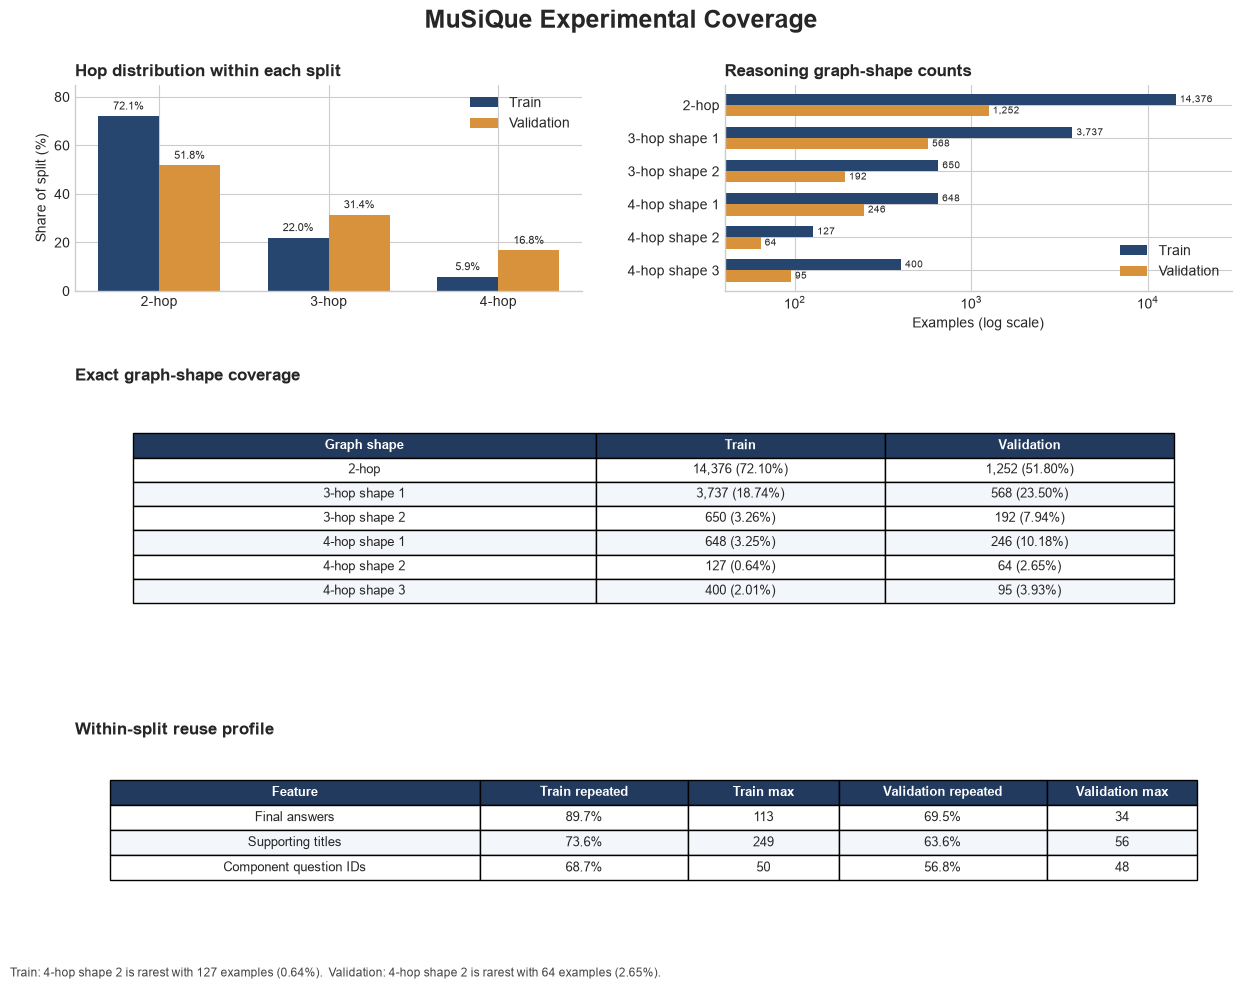

In [10]:
TRAIN_COLOR = "#27466F"
VALIDATION_COLOR = "#D8923B"
SPLIT_COLORS = {"train": TRAIN_COLOR, "validation": VALIDATION_COLOR}

fig = plt.figure(figsize=(13, 10))
fig.patch.set_facecolor("white")
grid = fig.add_gridspec(3, 2, height_ratios=[2.2, 2.7, 1.8], hspace=0.48, wspace=0.28)
hop_axis = fig.add_subplot(grid[0, 0])
graph_axis = fig.add_subplot(grid[0, 1])
coverage_axis = fig.add_subplot(grid[1, :])
reuse_axis = fig.add_subplot(grid[2, :])
fig.suptitle("MuSiQue Experimental Coverage", fontsize=18, fontweight="bold", y=0.985)

bar_width = 0.36
hop_positions = list(range(len(HOP_ORDER)))
for offset, split_name in zip((-bar_width / 2, bar_width / 2), splits):
    split_hops = hop_coverage.set_index(["split", "hop_count"]).loc[split_name]
    percentages = [split_hops.loc[hop, "split_share_pct"] for hop in HOP_ORDER]
    bars = hop_axis.bar(
        [position + offset for position in hop_positions],
        percentages,
        width=bar_width,
        color=SPLIT_COLORS[split_name],
        label=split_name.title(),
    )
    hop_axis.bar_label(bars, labels=[f"{value:.1f}%" for value in percentages], padding=3, fontsize=8)

hop_axis.set_title("Hop distribution within each split", loc="left", fontweight="bold")
hop_axis.set_xticks(hop_positions, [f"{hop}-hop" for hop in HOP_ORDER])
hop_axis.set_ylabel("Share of split (%)")
hop_axis.set_ylim(0, max(hop_coverage["split_share_pct"]) * 1.18)
hop_axis.legend(frameon=False)
hop_axis.spines[["top", "right"]].set_visible(False)

graph_positions = list(range(len(GRAPH_ORDER)))
graph_bar_height = 0.34
for offset, split_name in zip((-graph_bar_height / 2, graph_bar_height / 2), splits):
    split_graphs = graph_coverage.set_index(["split", "graph_code"]).loc[split_name]
    counts = [int(split_graphs.loc[graph_code, "count"]) for graph_code in GRAPH_ORDER]
    bars = graph_axis.barh(
        [position + offset for position in graph_positions],
        counts,
        height=graph_bar_height,
        color=SPLIT_COLORS[split_name],
        label=split_name.title(),
    )
    graph_axis.bar_label(bars, labels=[f"{count:,}" for count in counts], padding=3, fontsize=7.5)

graph_axis.set_title("Reasoning graph-shape counts", loc="left", fontweight="bold")
graph_axis.set_yticks(graph_positions, [GRAPH_LABELS[code] for code in GRAPH_ORDER])
graph_axis.invert_yaxis()
graph_axis.set_xscale("log")
graph_axis.set_xlabel("Examples (log scale)")
graph_axis.set_xlim(40, 30000)
graph_axis.legend(frameon=False, loc="lower right")
graph_axis.spines[["top", "right"]].set_visible(False)

coverage_axis.axis("off")
coverage_axis.set_title("Exact graph-shape coverage", loc="left", fontweight="bold", pad=8)
coverage_rows = []
for graph_code in GRAPH_ORDER:
    row = {"Graph shape": GRAPH_LABELS[graph_code]}
    for split_name in splits:
        result = graph_coverage.set_index(["split", "graph_code"]).loc[(split_name, graph_code)]
        row[split_name.title()] = f"{int(result['count']):,} ({result['split_share_pct']:.2f}%)"
    coverage_rows.append(row)
coverage_for_figure = pd.DataFrame(coverage_rows)
coverage_artist = coverage_axis.table(
    cellText=coverage_for_figure.values,
    colLabels=coverage_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.40, 0.25, 0.25],
    loc="center",
)
coverage_artist.auto_set_font_size(False)
coverage_artist.set_fontsize(9)
coverage_artist.scale(1, 1.35)

reuse_axis.axis("off")
reuse_axis.set_title("Within-split reuse profile", loc="left", fontweight="bold", pad=8)
reuse_rows = []
for feature_name in ("Final answers", "Supporting titles", "Component question IDs"):
    row = {"Feature": feature_name}
    for split_name in splits:
        result = reuse_profile.set_index(["split", "feature"]).loc[(split_name, feature_name)]
        row[f"{split_name.title()} repeated"] = f"{result['repeated_occurrence_pct']:.1f}%"
        row[f"{split_name.title()} max"] = f"{int(result['maximum_occurrences_for_one_value']):,}"
    reuse_rows.append(row)
reuse_for_figure = pd.DataFrame(reuse_rows)
reuse_artist = reuse_axis.table(
    cellText=reuse_for_figure.values,
    colLabels=reuse_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.32, 0.18, 0.13, 0.18, 0.13],
    loc="center",
)
reuse_artist.auto_set_font_size(False)
reuse_artist.set_fontsize(9)
reuse_artist.scale(1, 1.4)

for table_artist in (coverage_artist, reuse_artist):
    for (row_index, _), cell in table_artist.get_celld().items():
        if row_index == 0:
            cell.set_facecolor("#223A5E")
            cell.set_text_props(color="white", fontweight="bold")
        elif row_index % 2 == 0:
            cell.set_facecolor("#F3F6FA")

rarest_notes = []
for row in rarest_strata.itertuples(index=False):
    rarest_notes.append(
        f"{row.split.title()}: {row.graph_shape} is rarest with {row.count:,} examples ({row.split_share_pct:.2f}%)."
    )
fig.text(0.03, 0.018, "  ".join(rarest_notes), fontsize=8.5, color="#444444")
fig.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.08, hspace=0.60, wspace=0.28)

coverage_artifact_stem = "split_hop_graph_distribution"
coverage_artifact_paths = []
for file_format in ("pdf", "svg"):
    artifact_path = FIG_DIR / f"{coverage_artifact_stem}.{file_format}"
    fig.savefig(artifact_path, format=file_format, bbox_inches="tight")
    coverage_artifact_paths.append(artifact_path)

display(
    pd.DataFrame(
        {"saved_artifact": [str(path.relative_to(REPO_ROOT)) for path in coverage_artifact_paths]}
    )
)
plt.show()

### Interpretation for experiment design

The smallest graph-shape counts are the immediate sampling constraint. A purely proportional sample will preserve the dataset's two-hop dominance but may leave too few rare four-hop examples for stable class-conditional or activation-level comparisons. The displayed `rarest_strata` table makes that constraint explicit without selecting a sample prematurely.

High reuse rates mean that row-level counts overstate the amount of independent semantic material. When the project constructs probe-training and causal-evaluation subsets, component-question IDs and supporting titles should be considered as grouping variables. This section does not alter the official splits or prescribe a final sample size; it provides the coverage evidence needed for that later decision.